# 02 Structured Data EDA

This notebook covers **Step 2.2 — Structured Data EDA** only.

Goals:
1. Count testers and tasks for each of the 3 projects
2. Analyze cross-project tester participation
3. Explore task type distribution and Timeguide distribution
4. Analyze deviation between actual video duration and Timeguide

In [70]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
import re
BASE_DIR = Path.cwd()
RAW_DIR = BASE_DIR / "data" / "raw"
PROC_DIR = BASE_DIR / "data" / "processed"

In [67]:
# processed
windows = pd.read_csv(PROC_DIR / "windows.csv")
video_metadata = pd.read_csv(PROC_DIR / "video_metadata.csv")

# raw tasks
tasks_dep = pd.read_csv(RAW_DIR / "department-of-premier-and-cabinet-wa" / "coercive-control-support-tasks.csv")
tasks_sun = pd.read_csv(RAW_DIR / "suncorp-insurance" / "aami-website-tasks.csv")
tasks_uq  = pd.read_csv(RAW_DIR / "the-university-of-queensland" / "postgrad-enrolment-experience-tasks.csv")

tasks_dep["project"] = "department-of-premier-and-cabinet-wa"
tasks_sun["project"] = "suncorp-insurance"
tasks_uq["project"] = "the-university-of-queensland"

tasks_df = pd.concat([tasks_dep, tasks_sun, tasks_uq], ignore_index=True)

print("windows columns:", windows.columns.tolist())
print("video_metadata columns:", video_metadata.columns.tolist())
print("tasks_df columns:", tasks_df.columns.tolist())

windows columns: ['window_id', 'video_id', 'start_time', 'end_time', 'duration', 'text', 'word_count', 'segment_ids', 'project', 'video_filename', 'tester_name']
video_metadata columns: ['video_filename', 'tester_name', 'project', 'duration_seconds', 'file_size_mb', 'resolution', 'width', 'height', 'duration_ratio']
tasks_df columns: ['Order', 'Title', 'Instructions', 'Tips', 'Timeguide', 'TaskType', 'ExcludeFromCollation', 'RequiresPII', 'TaskURL', 'project']


In [68]:
# basic cleaning
windows["tester_name"] = windows["tester_name"].astype(str).str.strip()
windows["project"] = windows["project"].astype(str).str.strip()

video_metadata["project"] = video_metadata["project"].astype(str).str.strip()
video_metadata["tester_name"] = video_metadata["tester_name"].astype(str).str.strip()
video_metadata["duration_ratio"] = pd.to_numeric(video_metadata["duration_ratio"], errors="coerce")
video_metadata["duration_seconds"] = pd.to_numeric(video_metadata["duration_seconds"], errors="coerce")

tasks_df["project"] = tasks_df["project"].astype(str).str.strip()
tasks_df["Order"] = pd.to_numeric(tasks_df["Order"], errors="coerce")
tasks_df["TaskType"] = tasks_df["TaskType"].astype(str).str.strip()
tasks_df["Timeguide"] = tasks_df["Timeguide"].astype(str).str.strip()

In [71]:
# helper: convert Timeguide text to numeric minutes
def parse_timeguide_to_minutes(x):
    if pd.isna(x):
        return None
    
    x = str(x).strip().lower()
    if x == "" or x == "nan":
        return None
    
    # examples:
    # "10 mins max"
    # "15 mins max "
    # "30 seconds or less"
    # "1 minute"
    num_match = re.search(r"(\d+(\.\d+)?)", x)
    if not num_match:
        return None
    
    value = float(num_match.group(1))
    
    if "second" in x:
        return value / 60
    if "min" in x:
        return value
    if "hour" in x:
        return value * 60
    
    return value

tasks_df["Timeguide_minutes"] = tasks_df["Timeguide"].apply(parse_timeguide_to_minutes)

In [72]:
# 1) 3个项目各有多少测试员、多少任务

tester_per_project = (
    windows.groupby("project")["tester_name"]
    .nunique()
    .reset_index(name="tester_count")
)

task_per_project = (
    tasks_df.groupby("project")["Order"]
    .nunique()
    .reset_index(name="task_count")
)

project_overview = tester_per_project.merge(task_per_project, on="project", how="outer")

print("=== Number of testers and tasks by project ===")
display(project_overview)

=== Number of testers and tasks by project ===


,project,tester_count,task_count
0,department-of-premier-and-cabinet-wa,17,14
1,suncorp-insurance,21,11
2,the-university-of-queensland,19,10


In [73]:
# 2) 测试员跨项目参与情况

tester_cross_project = (
    windows.groupby("tester_name")["project"]
    .nunique()
    .reset_index(name="project_count")
    .sort_values(["project_count", "tester_name"], ascending=[False, True])
)

cross_project_testers = tester_cross_project[tester_cross_project["project_count"] > 1]

print("=== Tester cross-project participation ===")
display(tester_cross_project)

print("=== Testers involved in more than one project ===")
display(cross_project_testers)

print("Number of cross-project testers:", len(cross_project_testers))

=== Tester cross-project participation ===


,tester_name,project_count
0,Sharelinsonny,3
5,ghum,3
6,giuliaclemente26,3
7,gracieha22,3
11,laurenrosemetzler,3
12,margieflint,3
13,marychaunguyen,3
18,ramazankawish,3
19,reececraigie,3
20,reneerussell99,3


=== Testers involved in more than one project ===


,tester_name,project_count
0,Sharelinsonny,3
5,ghum,3
6,giuliaclemente26,3
7,gracieha22,3
11,laurenrosemetzler,3
12,margieflint,3
13,marychaunguyen,3
18,ramazankawish,3
19,reececraigie,3
20,reneerussell99,3


Number of cross-project testers: 18


In [74]:
# 3) 任务类型分布

task_type_dist = (
    tasks_df["TaskType"]
    .replace({"nan": pd.NA, "": pd.NA})
    .value_counts(dropna=False)
    .reset_index()
)
task_type_dist.columns = ["TaskType", "count"]

print("=== Task type distribution ===")
display(task_type_dist)

=== Task type distribution ===


,TaskType,count
0,CNT,5
1,SRH,5
2,<NA>,3
3,BRD,2
4,NAV,2
5,FRM,1
6,PDF,1
7,CNT;LND,1
8,SRH;HOM,1
9,WEB,1


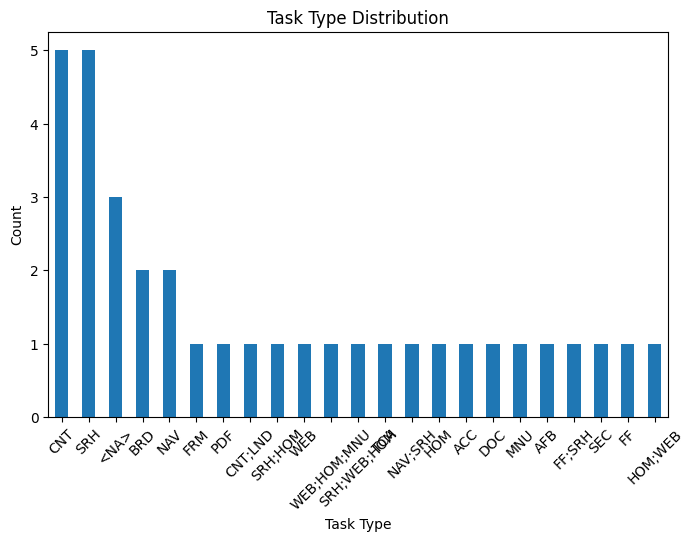

In [75]:
plt.figure(figsize=(8, 5))
tasks_df["TaskType"].replace({"nan": pd.NA, "": pd.NA}).value_counts(dropna=False).plot(kind="bar")
plt.title("Task Type Distribution")
plt.xlabel("Task Type")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.show()

In [76]:
# 3) Timeguide 分布

print("=== Timeguide summary (minutes) ===")
display(tasks_df["Timeguide_minutes"].describe())

display(tasks_df[["project", "Title", "Timeguide", "Timeguide_minutes"]].head(10))

=== Timeguide summary (minutes) ===


count    35.000000
mean     11.928571
std       7.664033
min       0.500000
25%      10.000000
50%      10.000000
75%      15.000000
max      45.000000
Name: Timeguide_minutes, dtype: float64

,project,Title,Timeguide,Timeguide_minutes
0,department-of-premier-and-cabinet-wa,Exploring Information Pathways,10 mins max,10.0
1,department-of-premier-and-cabinet-wa,Fact Sheet (PDF),10 mins max,10.0
2,department-of-premier-and-cabinet-wa,Providing Feedback via the Website,10 mins,10.0
3,department-of-premier-and-cabinet-wa,WA Government Homepage,10 mins max,10.0
4,department-of-premier-and-cabinet-wa,Pathways to Learn more,10 mins max,10.0
5,department-of-premier-and-cabinet-wa,Critical Review of the Coercive Control Landing Page,10 mins max,10.0
6,department-of-premier-and-cabinet-wa,Seeking Information About a Concerning Situation,5 mins max,5.0
7,department-of-premier-and-cabinet-wa,Critical Review of the Family and Domestic Violence Landing Page,5 mins max,5.0
8,department-of-premier-and-cabinet-wa,Terminology,5 mins max,5.0
9,department-of-premier-and-cabinet-wa,Thanks for listening WA,1 min max,1.0


Timeguide_minutes
0.5      1
1.0      2
5.0      4
10.0    14
15.0    10
20.0     3
45.0     1
Name: count, dtype: int64

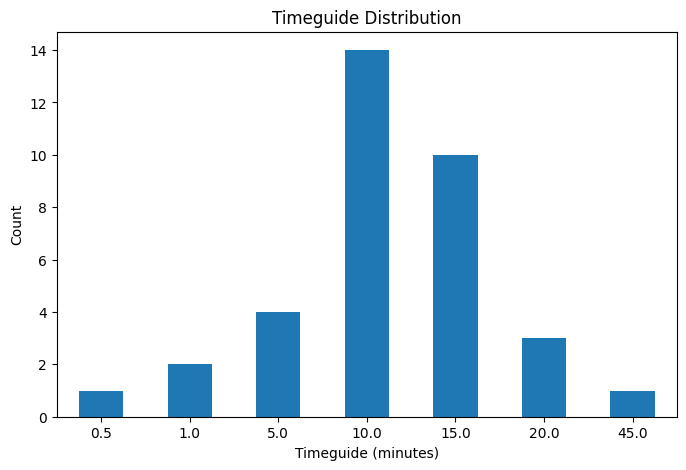

In [83]:
timeguide_counts = tasks_df["Timeguide_minutes"].value_counts().sort_index()

display(timeguide_counts)

plt.figure(figsize=(8, 5))
timeguide_counts.plot(kind="bar")
plt.title("Timeguide Distribution")
plt.xlabel("Timeguide (minutes)")
plt.ylabel("Count")
plt.xticks(rotation=0)
plt.show()

In [78]:
# optional: Timeguide by project
timeguide_by_project = (
    tasks_df.groupby("project")["Timeguide_minutes"]
    .describe()
)

print("=== Timeguide distribution by project ===")
display(timeguide_by_project)

=== Timeguide distribution by project ===


,count,mean,std,min,25%,50%,75%,max
project,,,,,,,,
department-of-premier-and-cabinet-wa,14.0,9.357143,4.601123,1.0,6.25,10.0,10.00,20.0
suncorp-insurance,11.0,10.954545,4.245318,0.5,10.00,10.0,15.00,15.0
the-university-of-queensland,10.0,16.600000,11.644741,1.0,15.00,15.0,18.75,45.0


In [79]:
# 4) 视频时长 vs Timeguide 的偏差分布
# 你已经有 duration_ratio，可直接用

print("=== Duration ratio summary ===")
display(video_metadata["duration_ratio"].describe())

=== Duration ratio summary ===


count    15.000000
mean      5.655233
std       2.768543
min       1.158000
25%       3.676450
50%       6.074300
75%       7.718800
max       9.579300
Name: duration_ratio, dtype: float64

In [80]:
# optional: identify extreme deviations, aligned with later Layer 1 threshold idea
duration_anomalies = video_metadata[
    (video_metadata["duration_ratio"] < 0.3) |
    (video_metadata["duration_ratio"] > 3.0)
].copy()

print("=== Videos with extreme duration deviation ===")
display(duration_anomalies[["project", "tester_name", "video_filename", "duration_seconds", "duration_ratio"]])

=== Videos with extreme duration deviation ===


,project,tester_name,video_filename,duration_seconds,duration_ratio
0,the-university-of-queensland,ramazankawish,project_8aeb4cdb-106f-47c1-b6e6-867344ce673b_ramazankawish_video.mp4,7558.28,8.3981
1,the-university-of-queensland,terryaflint17,project_8aeb4cdb-106f-47c1-b6e6-867344ce673b_terryaflint17_video.mp4,6154.40,6.8382
4,the-university-of-queensland,ghum,project_8aeb4cdb-106f-47c1-b6e6-867344ce673b_ghum_video.mp4,5861.50,6.5128
5,the-university-of-queensland,reneerussell99,project_8aeb4cdb-106f-47c1-b6e6-867344ce673b_reneerussell99_video.mp4,3624.60,4.0273
6,department-of-premier-and-cabinet-wa,ramazankawish,project_1f7f2859-ac90-4696-b89f-1077aa6040be_ramazankawish_video.mp4,5477.44,9.1291
7,department-of-premier-and-cabinet-wa,terryaflint17,project_1f7f2859-ac90-4696-b89f-1077aa6040be_terryaflint17_video.mp4,5100.40,8.5007
8,department-of-premier-and-cabinet-wa,ghum,project_1f7f2859-ac90-4696-b89f-1077aa6040be_ghum_video.mp4,5747.60,9.5793
9,department-of-premier-and-cabinet-wa,reneerussell99,project_1f7f2859-ac90-4696-b89f-1077aa6040be_reneerussell99_video.mp4,4223.70,7.0395
10,suncorp-insurance,reneerussell99,project_73052603-e4d8-4aed-a9ce-cc5db15e6355_reneerussell99_video.mp4,2993.00,3.3256
11,suncorp-insurance,ramazankawish,project_73052603-e4d8-4aed-a9ce-cc5db15e6355_ramazankawish_video.mp4,4732.49,5.2583


In [81]:
# final summary tables if you want to save them
OUTPUT_DIR = BASE_DIR / "outputs"
OUTPUT_DIR.mkdir(exist_ok=True)

project_overview.to_csv(OUTPUT_DIR / "step2_2_project_overview.csv", index=False)
tester_cross_project.to_csv(OUTPUT_DIR / "step2_2_tester_cross_project.csv", index=False)
task_type_dist.to_csv(OUTPUT_DIR / "step2_2_task_type_distribution.csv", index=False)
tasks_df.to_csv(OUTPUT_DIR / "step2_2_tasks_with_timeguide_minutes.csv", index=False)

print("Saved Step 2.2 outputs to:", OUTPUT_DIR)

Saved Step 2.2 outputs to: c:\Users\14377\usyd-03-2025-cs20-1\usyd-03-2025-cs20-1\outputs


## Step 2.2 Summary

This analysis examines structured data across three projects, focusing on tester participation, task design, and recording behavior.

The number of testers is relatively consistent across projects, while the number of tasks varies slightly, indicating differences in project scope. A notable finding is that 18 testers participated across multiple projects, enabling meaningful cross-project performance tracking.

Task type distribution appears fragmented due to combined labels, suggesting that tasks are often multi-dimensional. Timeguide analysis shows that most tasks are expected to be completed within 10–15 minutes, although the University of Queensland project includes longer tasks on average.

Most importantly, the duration ratio analysis reveals that actual video durations significantly exceed expected Timeguide values, with an average ratio of 5.65. This indicates inefficiencies or extended interactions during testing and provides strong support for implementing rule-based anomaly detection in later stages of the pipeline.